In [1]:
import os
import matplotlib.pyplot as plt


base_path = "data/speed_benchmarking"
files = os.listdir(base_path)

model_times = {}
for f in files:
    model = f.split(".")[0]
    model_times[model] = []
    with open(f"{base_path}/{f}") as fh:
        lines = fh.readlines()
    for line in lines:
        time = line.split(" ")[-1].strip()
        model_times[model].append(float(time))

print(model_times)

{'contextfold': [74.28443741798401, 73.83920645713806, 75.94040179252625, 74.90207839012146, 76.4187879562378, 74.15560030937195, 77.56217765808105, 73.00006866455078, 76.93260860443115, 75.0011100769043], 'mxfold2': [567.4103055000305, 429.03706073760986, 540.8692002296448, 510.07439136505127, 488.4573566913605, 438.37126755714417, 575.6587028503418, 605.5028910636902, 559.4732282161713, 569.0943803787231], 'ipknot': [162.80556511878967, 162.24710059165955, 163.05851030349731, 162.59606266021729, 163.24463820457458, 160.3383378982544, 161.2635838985443, 161.34693336486816, 160.6804633140564, 160.52699613571167], 'rnastructure': [389.4812729358673, 390.0327305793762, 390.65089297294617, 387.94928908348083, 386.89531683921814, 386.80338644981384, 385.94165658950806, 389.1738283634186, 392.88188648223877, 398.6710934638977], 'spot-rna': [16629.0, 16431.0, 16465.0, 16396.0, 16507.0, 16600.0, 16337.0, 16426.0, 16367.0, 16386.0], 'rnafold': [34.39598512649536, 34.15180277824402, 34.23884272

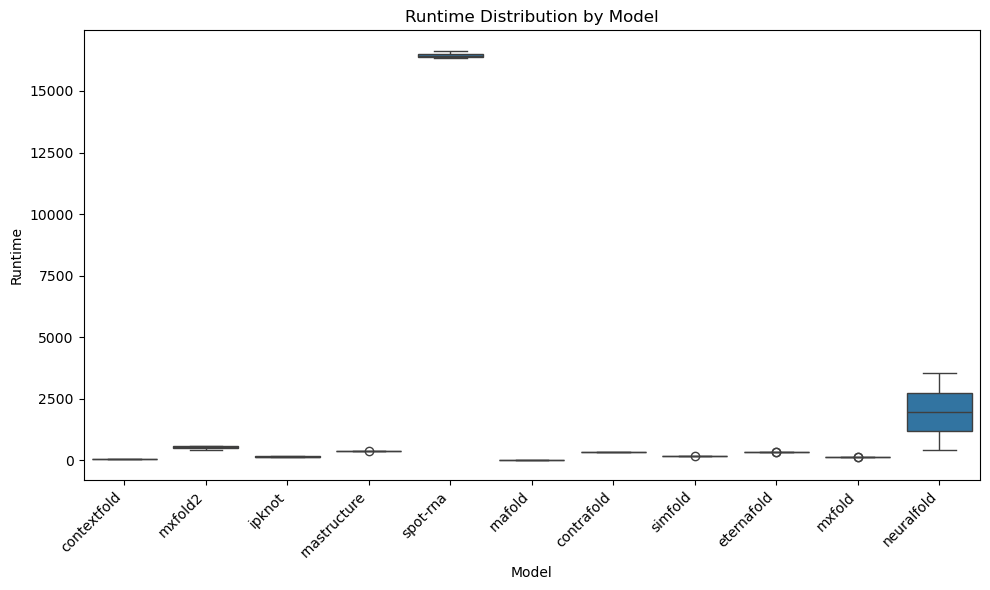

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plot_df = pd.DataFrame(
    [
        {"model": model, "time": t}
        for model, times in model_times.items()
        for t in times
    ]
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="model",
    y="time"
)

plt.xlabel("Model")
plt.ylabel("Runtime in seconds")
plt.title("Runtime Distribution by Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

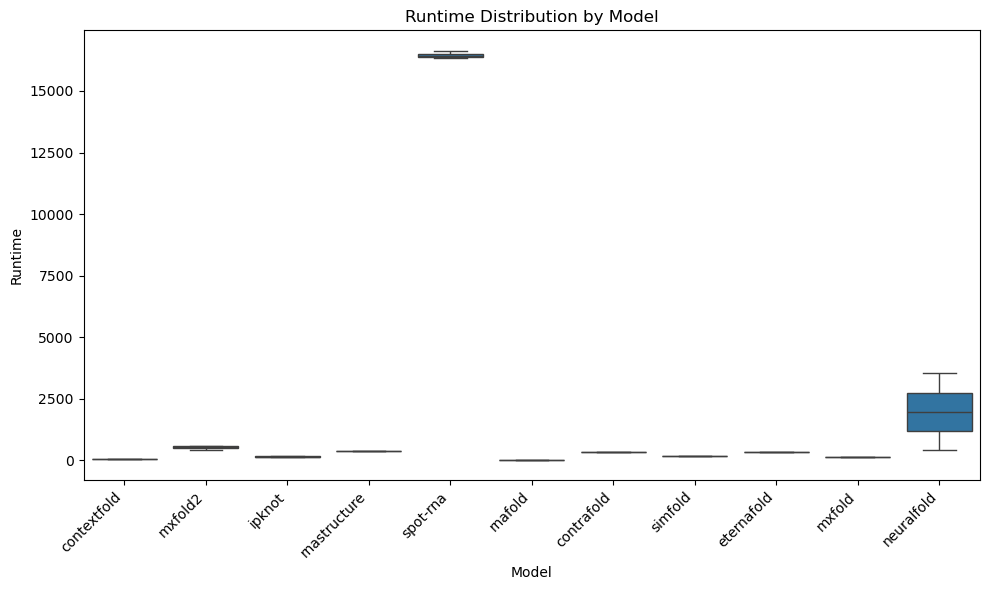

In [3]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="model",
    y="time",
    showfliers=False
)

plt.xlabel("Model")
plt.ylabel("Runtime")
plt.title("Runtime Distribution by Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

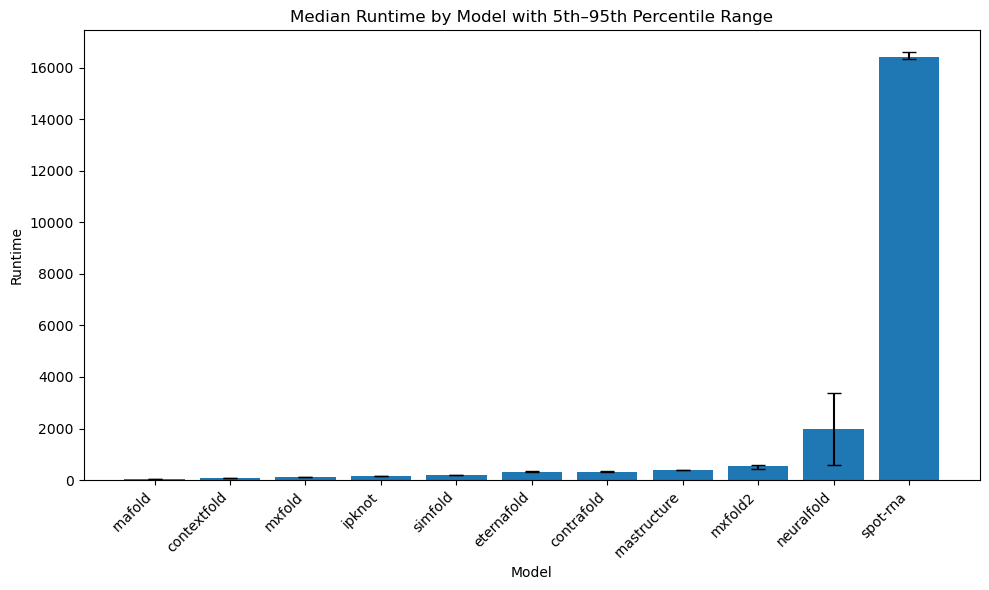

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert dictionary to long-form DataFrame
plot_df = pd.DataFrame(
    [
        {"model": model, "time": t}
        for model, times in model_times.items()
        for t in times
    ]
)

summary = (
    plot_df.groupby("model")["time"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q05=lambda x: x.quantile(0.05),
        q95=lambda x: x.quantile(0.95),
    )
    .reset_index()
)

# Optional: sort by median runtime
summary = summary.sort_values("median")

lower_error = summary["median"] - summary["q05"]
upper_error = summary["q95"] - summary["median"]

plt.figure(figsize=(10, 6))

plt.bar(
    summary["model"],
    summary["median"],
    yerr=[lower_error, upper_error],
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("Runtime")
plt.title("Median Runtime by Model with 5th–95th Percentile Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Convert dictionary to long-form DataFrame
plot_df = pd.DataFrame(
    [
        {"model": model, "time": t}
        for model, times in model_times.items()
        for t in times
    ]
)

summary = (
    plot_df.groupby("model")["time"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q05=lambda x: x.quantile(0.05),
        q95=lambda x: x.quantile(0.95),
    )
    .reset_index()
)

# Sort by median runtime
summary = summary.sort_values("median")

lower_error = summary["median"] - summary["q05"]
upper_error = summary["q95"] - summary["median"]

models = summary["model"]
x = np.arange(len(models))

# Create two stacked axes
fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [1, 2]}
)

# Plot the same bars on both axes
ax_top.bar(
    x,
    summary["median"],
    yerr=[lower_error, upper_error],
    capsize=5
)

ax_bottom.bar(
    x,
    summary["median"],
    yerr=[lower_error, upper_error],
    capsize=5
)

# Set the y-axis limits
ax_bottom.set_ylim(0, 3500)
ax_top.set_ylim(3500, 17000)

# Hide the spines between the two axes
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)

ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()

# Add diagonal break marks
d = 0.00

kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels and formatting
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(models, rotation=45, ha="right")

ax_bottom.set_xlabel("Model")
fig.text(0.04, 0.5, "Runtime", va="center", rotation="vertical")

ax_top.set_title("Median Runtime by Model with 5th–95th Percentile Range")

plt.tight_layout()
plt.savefig("speed_comparison.png", dpi=500)
plt.show()

NameError: name 'model_times' is not defined